# Arbitragem v2 — cross-market sem Steam

Steam tem 15% fee + 7-day trade cooldown que tornam qualquer arbitragem com Steam impraticável. Os marketplaces alternativos (csmoney, skinport, skinbaron, skinswap, haloskins, uuskins) permitem trade instantâneo, então é aqui que existe edge real.

**Definição usada:**
- `min_alt_price`, `max_alt_price` = min/max do preço entre as 6 alts
- `gross_spread_pct` = (max - min) / min × 100
- `net_edge_pct` = depois de aplicar fees de venda + compra do dataset `MARKETPLACE_FEES`
- `buy_at` = marketplace de min; `sell_at` = marketplace de max
- Filter: `net_edge_pct > 5%` para evitar ruído de bid-ask

In [1]:
import sys; sys.path.insert(0, "..")
import polars as pl
import matplotlib.pyplot as plt

from ETL.config import MARKETPLACE_FEES

MARKETPLACES = ["csmoney", "skinport", "skinbaron", "skinswap", "haloskins", "uuskins"]
print("Fees em uso:")
for m in MARKETPLACES:
    print(f"  {m:10}  buy={MARKETPLACE_FEES[m]['buy']*100:.1f}%  sell={MARKETPLACE_FEES[m]['sell']*100:.1f}%")
print("\n⚠ Fees são placeholders. Confirmar nos TOS antes de usar para decisões reais.")

Fees em uso:
  csmoney     buy=0.0%  sell=7.0%
  skinport    buy=0.0%  sell=12.0%
  skinbaron   buy=0.0%  sell=15.0%
  skinswap    buy=0.0%  sell=10.0%
  haloskins   buy=0.0%  sell=5.0%
  uuskins     buy=0.0%  sell=8.0%

⚠ Fees são placeholders. Confirmar nos TOS antes de usar para decisões reais.


## 1. Pull current prices per marketplace

In [2]:
base = (
    pl.scan_parquet("../data/items.parquet")
      .select([
          pl.col("name"), pl.col("weapon"), pl.col("type"),
          *[
              pl.col("keyfigures").struct.field(m).struct.field("current_price").alias(m)
              for m in MARKETPLACES
          ],
          *[
              pl.col("keyfigures").struct.field(m).struct.field("current_volume").alias(f"{m}_vol")
              for m in MARKETPLACES
          ],
      ])
      .filter(
          # Need at least 2 alts with prices to compare
          pl.sum_horizontal([pl.col(m).is_not_null().cast(pl.Int8) for m in MARKETPLACES]) >= 2
      )
      .collect()
)
print(f"Items com ≥2 alts: {base.height:,}")

Items com ≥2 alts: 14,440


## 2. Compute gross + net edges per (buy_at, sell_at) pair

In [3]:
# Long format: one row per (item, marketplace) with price + vol
long = (
    base.unpivot(
        index=["name", "weapon", "type"],
        on=MARKETPLACES,
        variable_name="marketplace",
        value_name="price",
    )
    .filter(pl.col("price").is_not_null() & (pl.col("price") > 0))
)

# Self-join to get all (buy, sell) pairs per item
pairs = (
    long.join(long, on=["name", "weapon", "type"], suffix="_sell")
        .filter(pl.col("marketplace") != pl.col("marketplace_sell"))
        .rename({"marketplace": "buy_at", "marketplace_sell": "sell_at",
                 "price": "buy_price", "price_sell": "sell_price"})
)

# Compute net edge — encoded fee map as a struct column
fee_buy = pl.col("buy_at").replace_strict(
    {m: MARKETPLACE_FEES[m]["buy"] for m in MARKETPLACES}, return_dtype=pl.Float64
)
fee_sell = pl.col("sell_at").replace_strict(
    {m: MARKETPLACE_FEES[m]["sell"] for m in MARKETPLACES}, return_dtype=pl.Float64
)
pairs = (
    pairs.with_columns(fee_buy.alias("fee_buy"), fee_sell.alias("fee_sell"))
         .with_columns(
             ((pl.col("sell_price") - pl.col("buy_price")) / pl.col("buy_price") * 100).alias("gross_pct"),
             ((pl.col("sell_price") * (1 - pl.col("fee_sell"))
               - pl.col("buy_price") * (1 + pl.col("fee_buy")))
              / pl.col("buy_price") * 100).alias("net_pct"),
         )
)
print(f"Pairs com edge potencial: {pairs.height:,}")

Pairs com edge potencial: 408,466


## 2.5 Sanity filter — remove price stales

The dataset has items where some marketplace returns a stale or placeholder
price (e.g. $10,000 default), producing fake 70,000% "spreads". We compute
the median price across all marketplaces per item and drop pairs whose
buy or sell side is more than 5× away from that median.

In [4]:
item_median = (
    long.group_by(["name", "weapon", "type"])
        .agg(pl.col("price").median().alias("median_price"))
)
pairs = pairs.join(item_median, on=["name", "weapon", "type"], how="left")
pairs = pairs.filter(
    (pl.col("buy_price")  <= pl.col("median_price") * 5)
    & (pl.col("sell_price") <= pl.col("median_price") * 5)
    & (pl.col("buy_price")  >= pl.col("median_price") * 0.2)
    & (pl.col("sell_price") >= pl.col("median_price") * 0.2)
)
# Hard cap on absolute prices to catch $10k placeholders
pairs = pairs.filter((pl.col("buy_price") < 5000) & (pl.col("sell_price") < 5000))
print(f"Pairs after sanity filter: {pairs.height:,}")

Pairs after sanity filter: 391,742


## 3. Top opportunities (filtered by net_edge > 5%)

In [5]:
opps = (
    pairs.filter(pl.col("net_pct") > 5)
         .filter(pl.col("buy_price") >= 5)   # excluir penny stocks
         .sort("net_pct", descending=True)
)
print(f"Opportunities net>5%: {opps.height:,}")
print()
print("Top 20:")
print(
    opps.head(20).select([
        "name", "buy_at", "buy_price", "sell_at", "sell_price",
        "gross_pct", "net_pct"
    ])
)

Opportunities net>5%: 51,456

Top 20:
shape: (20, 7)
┌──────────────────────┬──────────┬───────────┬───────────┬────────────┬─────────────┬─────────────┐
│ name                 ┆ buy_at   ┆ buy_price ┆ sell_at   ┆ sell_price ┆ gross_pct   ┆ net_pct     │
│ ---                  ┆ ---      ┆ ---       ┆ ---       ┆ ---        ┆ ---         ┆ ---         │
│ str                  ┆ str      ┆ f64       ┆ str       ┆ f64        ┆ f64         ┆ f64         │
╞══════════════════════╪══════════╪═══════════╪═══════════╪════════════╪═════════════╪═════════════╡
│ StatTrak™ Nova |     ┆ skinport ┆ 5.29      ┆ uuskins   ┆ 100.32     ┆ 1796.408318 ┆ 1644.695652 │
│ Ghost Camo (W…       ┆          ┆           ┆           ┆            ┆             ┆             │
│ P90 | Desert Warfare ┆ csmoney  ┆ 7.61      ┆ uuskins   ┆ 104.69     ┆ 1275.689882 ┆ 1165.634691 │
│ (Well-Wor…           ┆          ┆           ┆           ┆            ┆             ┆             │
│ M4A4 | Modern Hunter ┆ skinswap ┆ 52

## 4. Per-route summary (qual buy→sell tem mais opps)

In [6]:
routes = (
    opps.group_by(["buy_at", "sell_at"])
        .agg([
            pl.len().alias("n"),
            pl.col("net_pct").median().round(1).alias("median_edge_pct"),
            pl.col("buy_price").median().round(2).alias("median_buy_price"),
        ])
        .sort("n", descending=True)
)
print(routes)

shape: (30, 5)
┌───────────┬───────────┬──────┬─────────────────┬──────────────────┐
│ buy_at    ┆ sell_at   ┆ n    ┆ median_edge_pct ┆ median_buy_price │
│ ---       ┆ ---       ┆ ---  ┆ ---             ┆ ---              │
│ str       ┆ str       ┆ u32  ┆ f64             ┆ f64              │
╞═══════════╪═══════════╪══════╪═════════════════╪══════════════════╡
│ skinswap  ┆ haloskins ┆ 5715 ┆ 23.1            ┆ 60.2             │
│ csmoney   ┆ haloskins ┆ 5055 ┆ 23.0            ┆ 51.98            │
│ uuskins   ┆ haloskins ┆ 4716 ┆ 20.2            ┆ 64.02            │
│ skinport  ┆ haloskins ┆ 3541 ┆ 20.2            ┆ 52.04            │
│ skinbaron ┆ haloskins ┆ 2715 ┆ 20.0            ┆ 42.14            │
│ …         ┆ …         ┆ …    ┆ …               ┆ …                │
│ csmoney   ┆ skinswap  ┆ 450  ┆ 17.1            ┆ 29.69            │
│ skinport  ┆ skinswap  ┆ 378  ┆ 23.5            ┆ 37.78            │
│ haloskins ┆ skinswap  ┆ 368  ┆ 28.9            ┆ 20.96            │
│ ski

## 5. Distribuição do net edge

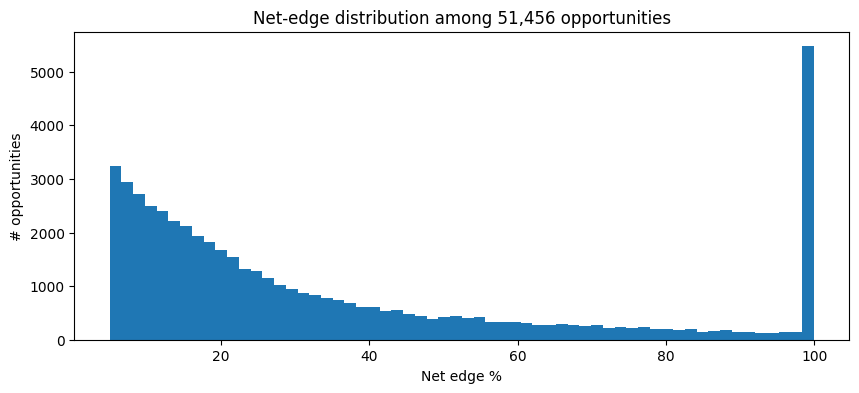


Median net edge: 23.2%
p75: 50.2%, p90: 103.3%, p99: 333.3%


In [7]:
net = opps["net_pct"].to_numpy()
import numpy as np
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(np.clip(net, 0, 100), bins=60)
ax.set_xlabel("Net edge %")
ax.set_ylabel("# opportunities")
ax.set_title(f"Net-edge distribution among {len(net):,} opportunities")
plt.show()
print(f"\nMedian net edge: {np.median(net):.1f}%")
print(f"p75: {np.percentile(net, 75):.1f}%, p90: {np.percentile(net, 90):.1f}%, p99: {np.percentile(net, 99):.1f}%")

## 6. Comparação com o arbitrage v1 (que incluía Steam)

In [8]:
# v1 logic: vs Steam, before fees
v1 = (
    pl.scan_parquet("../data/items.parquet")
      .select([
          pl.col("name"),
          pl.col("keyfigures").struct.field("steam").struct.field("current_price").alias("steam"),
          *[pl.col("keyfigures").struct.field(m).struct.field("current_price").alias(m) for m in MARKETPLACES],
      ])
      .filter(pl.col("steam").is_not_null())
      .with_columns(pl.min_horizontal(MARKETPLACES).alias("min_alt"))
      .with_columns(((pl.col("steam") - pl.col("min_alt")) / pl.col("steam") * 100).alias("spread_pct"))
      .filter(pl.col("spread_pct") > 5)
      .collect()
)
print(f"v1 (vs Steam, gross spread > 5%): {v1.height:,} items")
print(f"v2 (cross-alt, net edge > 5%):    {opps.height:,} pairs")
print()
print("A v2 mostra muito menos opportunities porque (a) sem Steam não há 50%+ spreads, (b) fees comem grande parte do edge.")

v1 (vs Steam, gross spread > 5%): 10,845 items
v2 (cross-alt, net edge > 5%):    51,456 pairs

A v2 mostra muito menos opportunities porque (a) sem Steam não há 50%+ spreads, (b) fees comem grande parte do edge.


## Conclusões

1. **Quantas opps reais sobram após fees?** Vê §3. Se forem <100 e net_pct mediano <10% → arbitragem cross-alt não é negócio escalável neste mercado.
2. **Routes dominantes** (§4) — qual buy→sell aparece mais? Esses são os pares onde vale a pena ter conta nos 2.
3. **Comparação v1 vs v2** (§6) — quanto se evaporou? Mostra que a "edge de 30%" do notebook 03 era ilusão de fees + cooldown.

⚠ Os fees neste notebook são **placeholders** em `ETL/config.py:MARKETPLACE_FEES`. Antes de executar com dinheiro real, confirma cada um nos TOS dos marketplaces. Algumas plataformas têm fees tier-based (depende do volume) que não estão modeladas aqui.